In [329]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [330]:
train_data=pd.read_excel('Data_Train.xlsx')

In [331]:
train_data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [332]:
train_data.shape

(10683, 11)

## Data cleaning

In [333]:
train_data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [334]:
train_data[train_data["Total_Stops"].isnull()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [335]:
train_data.dropna(inplace=True)

In [336]:
train_data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [337]:
train_data[train_data.duplicated(keep=False)].sort_values(by=train_data.columns.tolist())

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
6321,Air India,01/03/2019,Banglore,New Delhi,BLR → BOM → AMD → DEL,08:50,23:55 02 Mar,39h 5m,2 stops,No info,17135
9848,Air India,01/03/2019,Banglore,New Delhi,BLR → BOM → AMD → DEL,08:50,23:55 02 Mar,39h 5m,2 stops,No info,17135
572,Air India,03/03/2019,Banglore,New Delhi,BLR → DEL,21:10,23:55,2h 45m,non-stop,No info,7591
8168,Air India,03/03/2019,Banglore,New Delhi,BLR → DEL,21:10,23:55,2h 45m,non-stop,No info,7591
1495,Air India,1/04/2019,Kolkata,Banglore,CCU → DEL → COK → BLR,10:00,01:20 02 Apr,15h 20m,2 stops,No info,10408
...,...,...,...,...,...,...,...,...,...,...,...
2870,SpiceJet,24/03/2019,Banglore,New Delhi,BLR → DEL,05:45,08:35,2h 50m,non-stop,No check-in baggage included,4273
1535,SpiceJet,24/03/2019,Banglore,New Delhi,BLR → DEL,20:30,23:20,2h 50m,non-stop,No check-in baggage included,3873
3711,SpiceJet,24/03/2019,Banglore,New Delhi,BLR → DEL,20:30,23:20,2h 50m,non-stop,No check-in baggage included,3873
2634,Vistara,24/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,5403


In [338]:
train_data.drop_duplicates(inplace=True)

In [339]:
train_data[train_data.duplicated(keep=False)].sort_values(by=train_data.columns.tolist())

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price


In [340]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10462 non-null  object
 1   Date_of_Journey  10462 non-null  object
 2   Source           10462 non-null  object
 3   Destination      10462 non-null  object
 4   Route            10462 non-null  object
 5   Dep_Time         10462 non-null  object
 6   Arrival_Time     10462 non-null  object
 7   Duration         10462 non-null  object
 8   Total_Stops      10462 non-null  object
 9   Additional_Info  10462 non-null  object
 10  Price            10462 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 980.8+ KB


## Feature Engineering

In [341]:
data=train_data.copy()

In [342]:
data.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662


In [343]:
data.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [344]:
data["Date_of_Journey"]

0        24/03/2019
1         1/05/2019
2         9/06/2019
3        12/05/2019
4        01/03/2019
            ...    
10678     9/04/2019
10679    27/04/2019
10680    27/04/2019
10681    01/03/2019
10682     9/05/2019
Name: Date_of_Journey, Length: 10462, dtype: object

In [345]:
data["Date_of_Journey"] = pd.to_datetime(data["Date_of_Journey"], format="%d/%m/%Y")

In [346]:
data["Journey_Day"]=data["Date_of_Journey"].dt.day
data["Journey_Month"]=data["Date_of_Journey"].dt.month
data["Journey_Year"]=data["Date_of_Journey"].dt.year

In [347]:
data.head(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Year
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019


In [348]:
data["Arrival_Time_Hour"]=pd.to_datetime(data["Arrival_Time"]).dt.hour
data["Arrival_Time_Minute"]=pd.to_datetime(data["Arrival_Time"]).dt.minute

/var/folders/tq/60qy3rcj047_9hfymbjfwxwc0000gn/T/ipykernel_28433/2025792497.py:1: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/var/folders/tq/60qy3rcj047_9hfymbjfwxwc0000gn/T/ipykernel_28433/2025792497.py:2: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [349]:
data["Dep_Time_Hour"]=pd.to_datetime(data["Dep_Time"]).dt.hour
data["Dep_Time_Minute"]=pd.to_datetime(data["Dep_Time"]).dt.minute

/var/folders/tq/60qy3rcj047_9hfymbjfwxwc0000gn/T/ipykernel_28433/2757911057.py:1: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/var/folders/tq/60qy3rcj047_9hfymbjfwxwc0000gn/T/ipykernel_28433/2757911057.py:2: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [350]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Year,Arrival_Time_Hour,Arrival_Time_Minute,Dep_Time_Hour,Dep_Time_Minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,1,10,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,13,15,5,50
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019,4,25,9,25
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019,23,30,18,5
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019,21,35,16,50


## Data Analysis

In [351]:
def flight_dep_time(x):
    if x>4 and x<=8:
        return "Early_Morning"
    elif x>8 and x<=12:
        return "Morning"
    elif x>=12 and x<=16:
        return "Afternoon"
    elif x>16 and x<=20:
        return "Evening"
    elif x>20 and x<=24:
        return "Night"
    else:
        return "Late_Night"
    

In [352]:
data["Dep_Time_Hour"].apply(flight_dep_time)

0                Night
1        Early_Morning
2              Morning
3              Evening
4            Afternoon
             ...      
10678          Evening
10679          Evening
10680    Early_Morning
10681          Morning
10682          Morning
Name: Dep_Time_Hour, Length: 10462, dtype: object

<Axes: xlabel='Dep_Time_Hour'>

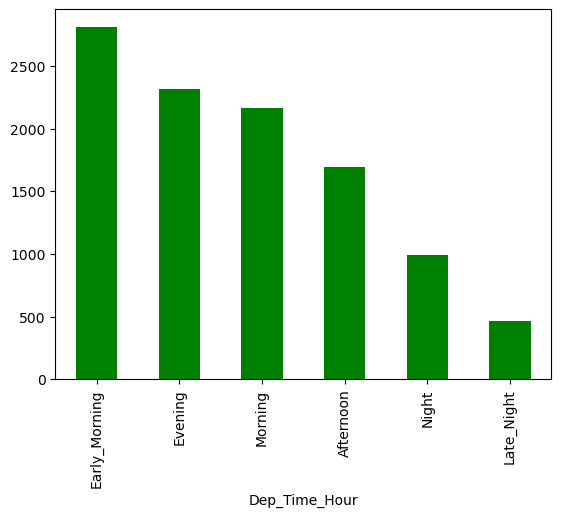

In [353]:
data["Dep_Time_Hour"].apply(flight_dep_time).value_counts().plot(kind="bar",color="green")

In [354]:
counts=data["Dep_Time_Hour"].apply(flight_dep_time).value_counts().reset_index()
counts.columns=["Dep_Shift","total_flights"]

In [355]:
import plotly.express as px

In [356]:
counts

,Dep_Shift,total_flights
0,Early_Morning,2814
1,Evening,2323
2,Morning,2170
3,Afternoon,1696
4,Night,995
5,Late_Night,464


In [357]:
px.bar(data_frame=counts,x="Dep_Shift",y="total_flights")

## Data Pre-processing on "Duration"

In [358]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Year,Arrival_Time_Hour,Arrival_Time_Minute,Dep_Time_Hour,Dep_Time_Minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,1,10,22,20
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,13,15,5,50
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019,4,25,9,25
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019,23,30,18,5
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019,21,35,16,50


In [359]:
def preprocess_duration(x):
    if "h" not in x:
        x="0h "+ " "+x
    elif "m" not in x:
        x=x+" "+"0m"
    return x    

In [360]:
data["Duration"]=data["Duration"].apply(preprocess_duration)

In [361]:
data["Duration"]

0        2h 50m
1        7h 25m
2        19h 0m
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680     3h 0m
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10462, dtype: object

In [362]:
data["Duration_hour"]=pd.to_timedelta(data["Duration"]).dt.components.hours

In [363]:
data["Duration_minute"]=pd.to_timedelta(data["Duration"]).dt.components.minutes

In [364]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Year,Arrival_Time_Hour,Arrival_Time_Minute,Dep_Time_Hour,Dep_Time_Minute,Duration_hour,Duration_minute
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,1,10,22,20,2,50
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,13,15,5,50,7,25
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h 0m,2 stops,No info,13882,9,6,2019,4,25,9,25,19,0
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019,23,30,18,5,5,25
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019,21,35,16,50,4,45


In [365]:
cols_to_drop=["Date_of_Journey","Arrival_Time","Dep_Time","Duration"]
data.drop(columns=cols_to_drop,axis=1,inplace=True)

In [366]:
data.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_Day', 'Journey_Month',
       'Journey_Year', 'Arrival_Time_Hour', 'Arrival_Time_Minute',
       'Dep_Time_Hour', 'Dep_Time_Minute', 'Duration_hour', 'Duration_minute'],
      dtype='object')

## Analyse weather Duration impact the price or not?

In [367]:
data.dtypes

Airline                object
Source                 object
Destination            object
Route                  object
Total_Stops            object
Additional_Info        object
Price                   int64
Journey_Day             int32
Journey_Month           int32
Journey_Year            int32
Arrival_Time_Hour       int32
Arrival_Time_Minute     int32
Dep_Time_Hour           int32
Dep_Time_Minute         int32
Duration_hour           int64
Duration_minute         int64
dtype: object

In [368]:
data["Duration_total_minutes"]=data["Duration_hour"]*60+data["Duration_minute"]

In [369]:
data.head(2)

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Year,Arrival_Time_Hour,Arrival_Time_Minute,Dep_Time_Hour,Dep_Time_Minute,Duration_hour,Duration_minute,Duration_total_minutes
0,IndiGo,Banglore,New Delhi,BLR → DEL,non-stop,No info,3897,24,3,2019,1,10,22,20,2,50,170
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2 stops,No info,7662,1,5,2019,13,15,5,50,7,25,445


<Axes: xlabel='Duration_total_minutes', ylabel='Price'>

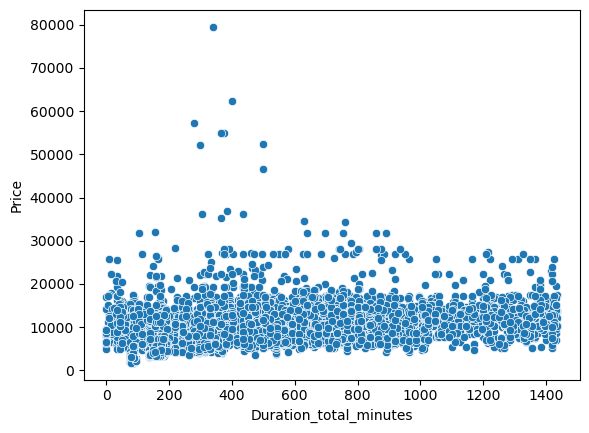

In [370]:
sns.scatterplot(x=data["Duration_total_minutes"],y=data["Price"])

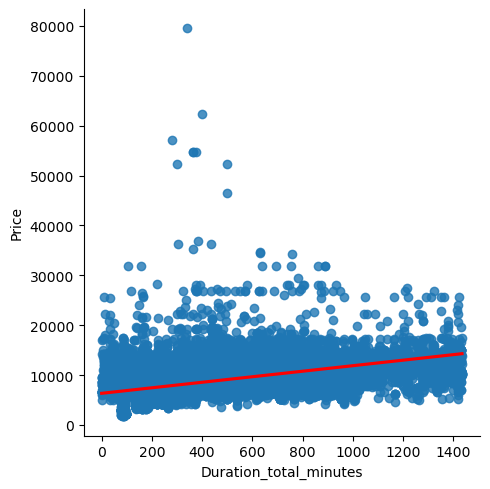

In [371]:
sns.lmplot(x="Duration_total_minutes",y="Price",data=data,line_kws={"color":"red"})

In [372]:
m, c=np.polyfit(data["Duration_total_minutes"],data["Price"],deg=1)

In [373]:
m

np.float64(5.5357527297722875)

In [374]:
c

np.float64(6345.852544716618)

In [375]:
#regression line for different airlines
data["Airline"].unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

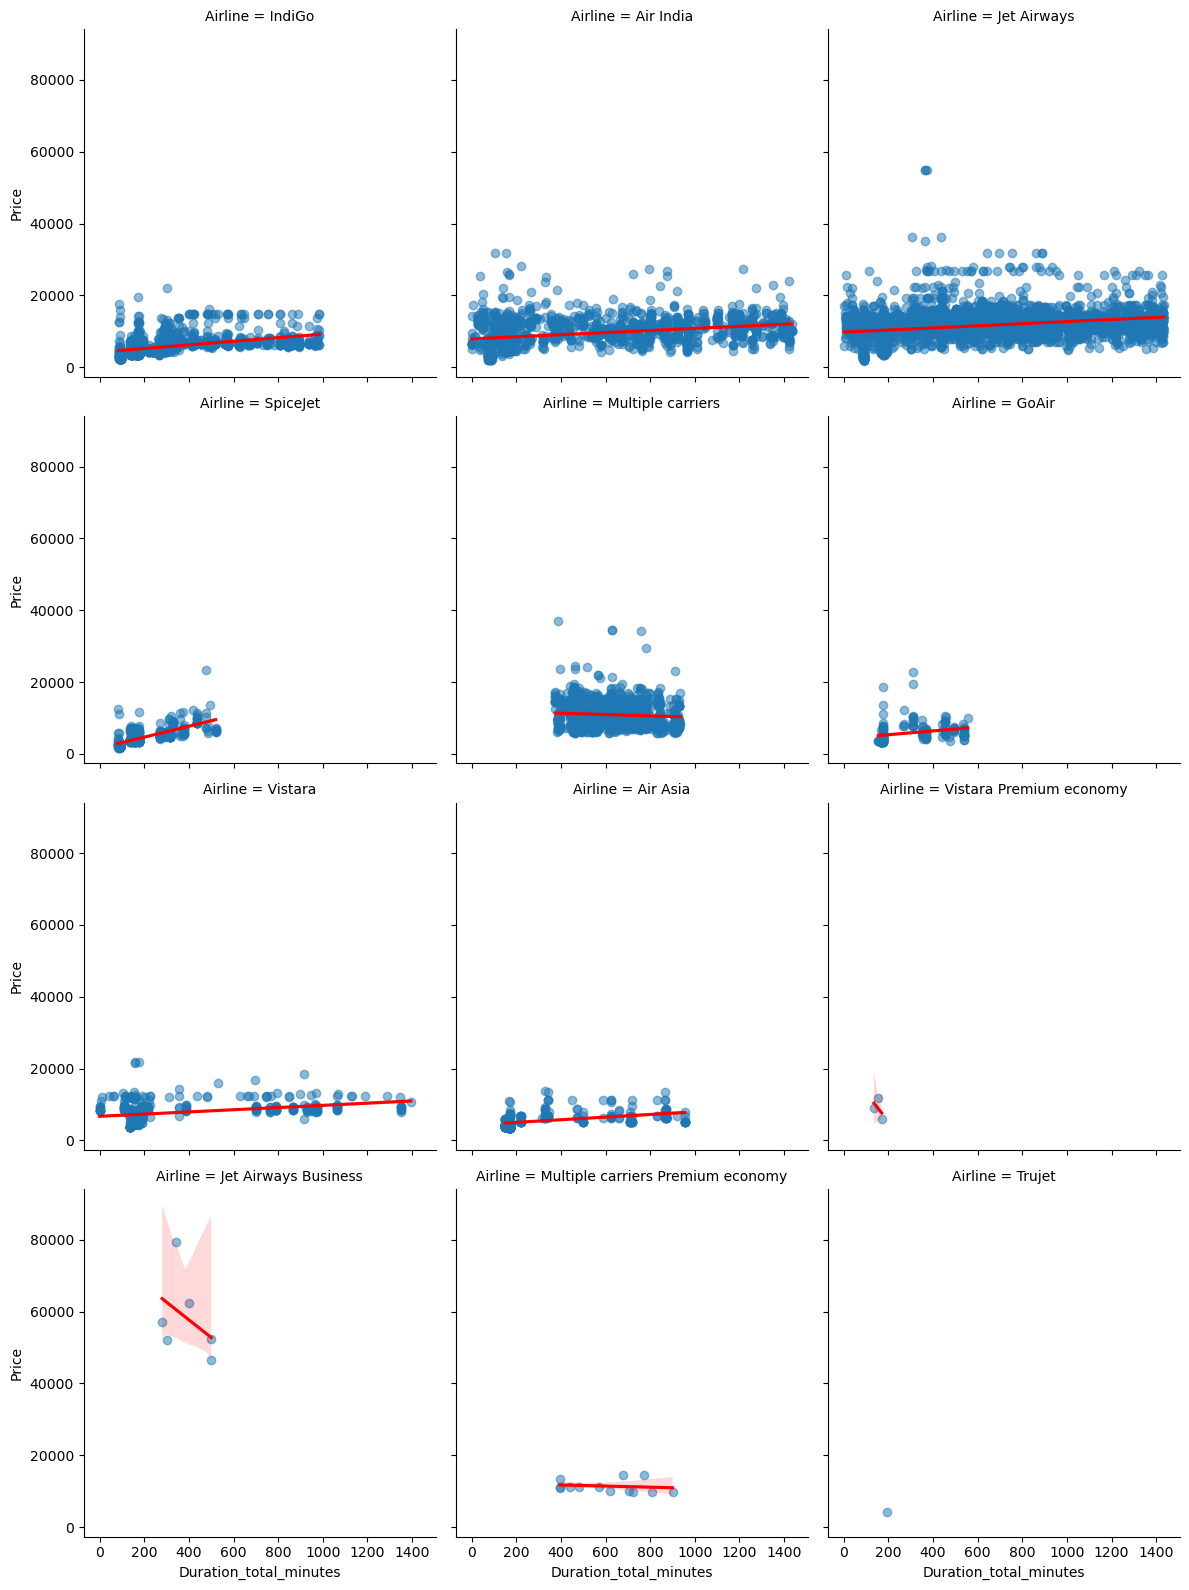

In [376]:
sns.lmplot(
    x="Duration_total_minutes", 
    y="Price", 
    data=data, 
    col="Airline",              # Creates a separate plot for each airline
    col_wrap=3,                 # Puts 3 plots per row
    height=4,                   # Adjusts the height of each mini-plot
    scatter_kws={'alpha': 0.5}, # Makes the dots slightly transparent (Note the comma!)
    line_kws={"color": "red"}   # Sets ONLY the regression line to red
)

## Applying the one-hot Encoding on data

In [377]:
dataframe=data.copy()

In [378]:
data.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_Day', 'Journey_Month',
       'Journey_Year', 'Arrival_Time_Hour', 'Arrival_Time_Minute',
       'Dep_Time_Hour', 'Dep_Time_Minute', 'Duration_hour', 'Duration_minute',
       'Duration_total_minutes'],
      dtype='object')

In [379]:
cat_col = [col for col in data.columns if data[col].dtype=="object"]

In [380]:
num_col = [col for col in data.columns if data[col].dtype!="object"]

In [381]:
data["Source"].unique()

array(['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai'], dtype=object)

In [382]:
source_dummies = pd.get_dummies(data["Source"],prefix="Source").astype(int)

In [383]:
source_dummies

,Source_Banglore,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,1,0,0,0,0
1,0,0,0,1,0
2,0,0,1,0,0
3,0,0,0,1,0
4,1,0,0,0,0
...,...,...,...,...,...
10678,0,0,0,1,0
10679,0,0,0,1,0
10680,1,0,0,0,0
10681,1,0,0,0,0


In [384]:
data=pd.concat([data,source_dummies],axis=1)

In [385]:
data["Airline"].unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [386]:
data.groupby("Airline")["Price"].mean().sort_values()

Airline
Trujet                                4140.000000
SpiceJet                              4335.841718
Air Asia                              5590.260188
IndiGo                                5668.469897
GoAir                                 5861.056701
Vistara                               7801.355649
Vistara Premium economy               8962.333333
Air India                             9556.608028
Multiple carriers                    10902.678094
Multiple carriers Premium economy    11418.846154
Jet Airways                          11599.021081
Jet Airways Business                 58358.666667
Name: Price, dtype: float64

In [387]:
airlines=data.groupby("Airline")["Price"].mean().sort_values().index

In [388]:
airlines

Index(['Trujet', 'SpiceJet', 'Air Asia', 'IndiGo', 'GoAir', 'Vistara',
       'Vistara Premium economy', 'Air India', 'Multiple carriers',
       'Multiple carriers Premium economy', 'Jet Airways',
       'Jet Airways Business'],
      dtype='object', name='Airline')

In [389]:
numbers=range(len(airlines))

In [390]:
dict_airline=dict(zip(airlines,numbers))

In [391]:
dict_airline

{'Trujet': 0,
 'SpiceJet': 1,
 'Air Asia': 2,
 'IndiGo': 3,
 'GoAir': 4,
 'Vistara': 5,
 'Vistara Premium economy': 6,
 'Air India': 7,
 'Multiple carriers': 8,
 'Multiple carriers Premium economy': 9,
 'Jet Airways': 10,
 'Jet Airways Business': 11}

In [392]:
data["Airline"] = data["Airline"].map(dict_airline)

In [393]:
data["Airline"]

0         3
1         7
2        10
3         3
4         3
         ..
10678     2
10679     7
10680    10
10681     5
10682     7
Name: Airline, Length: 10462, dtype: int64

In [394]:
cat_col

['Airline', 'Source', 'Destination', 'Route', 'Total_Stops', 'Additional_Info']

In [395]:
data["Destination"].unique()

array(['New Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Delhi', 'Hyderabad'],
      dtype=object)

In [396]:
data["Destination"].replace("New Delhi","Delhi",inplace=True)

/var/folders/tq/60qy3rcj047_9hfymbjfwxwc0000gn/T/ipykernel_28433/293571801.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [397]:
data["Destination"].unique()

array(['Delhi', 'Banglore', 'Cochin', 'Kolkata', 'Hyderabad'],
      dtype=object)

In [398]:
Destination=data.groupby("Destination")["Price"].mean().sort_values().index
Destination

Index(['Kolkata', 'Hyderabad', 'Delhi', 'Banglore', 'Cochin'], dtype='object', name='Destination')

In [399]:
dict_destination=dict(zip(Destination,numbers))
dict_destination

{'Kolkata': 0, 'Hyderabad': 1, 'Delhi': 2, 'Banglore': 3, 'Cochin': 4}

In [400]:
data["Destination"]=data["Destination"].map(dict_destination)

In [401]:
data["Destination"]

0        2
1        3
2        4
3        3
4        2
        ..
10678    3
10679    3
10680    2
10681    2
10682    4
Name: Destination, Length: 10462, dtype: int64

## Perform label encoding

In [402]:
cat_col

['Airline', 'Source', 'Destination', 'Route', 'Total_Stops', 'Additional_Info']

In [403]:
data["Total_Stops"].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [404]:
stop={'non-stop': 0, '2 stops': 2, '1 stop': 1, '3 stops': 3, '4 stops': 4}

In [405]:
data["Total_Stops"]=data["Total_Stops"].map(stop)

In [407]:
data["Total_Stops"]

0        0
1        2
2        2
3        1
4        1
        ..
10678    0
10679    0
10680    0
10681    0
10682    2
Name: Total_Stops, Length: 10462, dtype: int64

In [409]:
data.head(2)

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Year,...,Dep_Time_Hour,Dep_Time_Minute,Duration_hour,Duration_minute,Duration_total_minutes,Source_Banglore,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,3,Banglore,2,BLR → DEL,0,No info,3897,24,3,2019,...,22,20,2,50,170,1,0,0,0,0
1,7,Kolkata,3,CCU → IXR → BBI → BLR,2,No info,7662,1,5,2019,...,5,50,7,25,445,0,0,0,1,0


In [412]:
data["Additional_Info"].value_counts()/len(data)*100

Additional_Info
No info                         78.206844
In-flight meal not included     18.409482
No check-in baggage included     3.039572
1 Long layover                   0.181610
Change airports                  0.066909
Business class                   0.038234
No Info                          0.028675
1 Short layover                  0.009558
Red-eye flight                   0.009558
2 Long layover                   0.009558
Name: count, dtype: float64

In [413]:
cols_to_drop=["Additional_Info","Source","Duration_total_minutes","Journey_Year","Route"]
data.drop(columns=cols_to_drop,axis=1,inplace=True)

In [414]:
data.columns

Index(['Airline', 'Destination', 'Total_Stops', 'Price', 'Journey_Day',
       'Journey_Month', 'Arrival_Time_Hour', 'Arrival_Time_Minute',
       'Dep_Time_Hour', 'Dep_Time_Minute', 'Duration_hour', 'Duration_minute',
       'Source_Banglore', 'Source_Chennai', 'Source_Delhi', 'Source_Kolkata',
       'Source_Mumbai'],
      dtype='object')

## Lets perform the outlier detection

In [419]:
def plot(df, col):
    fig, (ax1,ax2,ax3)=plt.subplots(3,1)

    sns.distplot(df[col],ax=ax1)
    sns.boxplot(data=df,x=df[col],ax=ax2)
    sns.scatterplot(df[col],ax=ax3)


/var/folders/tq/60qy3rcj047_9hfymbjfwxwc0000gn/T/ipykernel_28433/3532638213.py:4: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




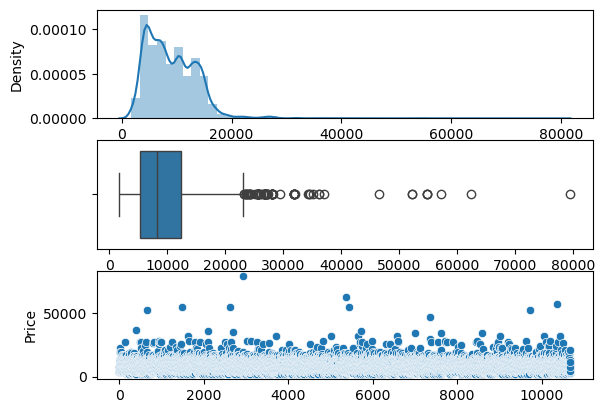

In [420]:
plot(data,"Price")


In [421]:
q1=data["Price"].quantile(0.25)
q3=data["Price"].quantile(0.75)
iqr=q3-q1   

In [422]:
max_limit=q3+1.5*iqr
min_limit=q1-1.5*iqr

In [426]:
[price for price in data["Price"] if price>max_limit or price<min_limit]

[27430,
 36983,
 26890,
 26890,
 25139,
 27210,
 52229,
 26743,
 26890,
 25735,
 27992,
 26890,
 26890,
 23583,
 26890,
 23533,
 24115,
 25735,
 54826,
 31783,
 27992,
 26890,
 26890,
 25430,
 36235,
 27210,
 26890,
 25735,
 54826,
 26890,
 35185,
 79512,
 28097,
 27992,
 26890,
 25735,
 26092,
 31825,
 25913,
 25735,
 27992,
 31825,
 23267,
 62427,
 54826,
 31825,
 25430,
 26890,
 36235,
 23843,
 26890,
 25735,
 28322,
 25735,
 25735,
 31825,
 26890,
 27992,
 34273,
 46490,
 29528,
 26890,
 26890,
 26890,
 34503,
 26890,
 27992,
 26890,
 26890,
 23170,
 24528,
 26890,
 27992,
 25735,
 34608,
 25703,
 26890,
 23528,
 31825,
 27282,
 25735,
 27992,
 52285,
 24017,
 31945,
 26890,
 24318,
 23677,
 27992,
 24210,
 57209,
 26890,
 31825,
 26480]

In [428]:
data["Price"]=np.where(data["Price"]>=35000, data["Price"].median(), data["Price"])

/var/folders/tq/60qy3rcj047_9hfymbjfwxwc0000gn/T/ipykernel_28433/3532638213.py:4: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




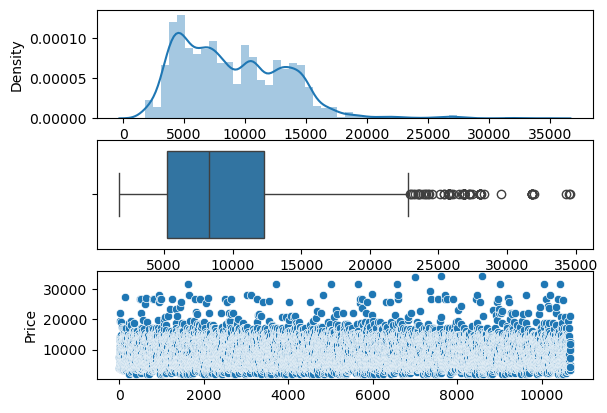

In [429]:
plot(data,"Price")

## Lets perfrom the feature selection

In [431]:
X=data.drop("Price",axis=1)
y=data["Price"]

In [432]:
from sklearn.ensemble import RandomForestRegressor

In [434]:
rf= RandomForestRegressor(n_estimators=100, random_state=42)

In [435]:
rf.fit(X,y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [436]:
rf.feature_importances_

array([0.17019686, 0.0204183 , 0.43923222, 0.13760558, 0.05888628,
       0.03068029, 0.02092248, 0.02737547, 0.02395082, 0.03210756,
       0.02147942, 0.00296323, 0.00127905, 0.00326645, 0.00474827,
       0.00488772])

In [439]:
X.columns  

Index(['Airline', 'Destination', 'Total_Stops', 'Journey_Day', 'Journey_Month',
       'Arrival_Time_Hour', 'Arrival_Time_Minute', 'Dep_Time_Hour',
       'Dep_Time_Minute', 'Duration_hour', 'Duration_minute',
       'Source_Banglore', 'Source_Chennai', 'Source_Delhi', 'Source_Kolkata',
       'Source_Mumbai'],
      dtype='object')

In [442]:
feature_importance=pd.DataFrame({"Feature":X.columns,"Importance":rf.feature_importances_}).sort_values(by="Importance",ascending=False)

In [443]:
feature_importance

,Feature,Importance
2,Total_Stops,0.439232
0,Airline,0.170197
3,Journey_Day,0.137606
4,Journey_Month,0.058886
9,Duration_hour,0.032108
5,Arrival_Time_Hour,0.030680
7,Dep_Time_Hour,0.027375
8,Dep_Time_Minute,0.023951
10,Duration_minute,0.021479
6,Arrival_Time_Minute,0.020922


## Lets Build the model

In [444]:
from sklearn.model_selection import train_test_split
train_X,test_X,train_y,test_y=train_test_split(X,y,test_size=0.25,random_state=42)

In [445]:
from sklearn.ensemble import RandomForestRegressor

In [446]:
ml_model=RandomForestRegressor()

In [447]:
ml_model.fit(train_X,train_y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [450]:
y_pred=ml_model.predict(test_X)

In [451]:
y_pred

array([15308.67533333,  3841.74666667,  4271.99133333, ...,
       14001.0085    , 11399.22      ,  4054.01066667], shape=(2616,))

In [452]:
from sklearn import metrics

In [453]:
metrics.mean_absolute_error(test_y,y_pred)

1185.9044562115807

## Model Evaluation I

In [454]:
metrics.r2_score(test_y,y_pred)

0.8074697521620307

### 0.8074697521620307 Model explain 81% of the varience in flight price

In [455]:
metrics.mean_absolute_percentage_error(test_y,y_pred)

0.13457861165486046

0.13457861165486046 % flight fare are away frim the actual price

## Saving the trained model

In [456]:
import pickle

In [457]:
with open("flight_price_rf_model.pkl","wb") as f:
    pickle.dump(ml_model,f)

In [459]:
model =open ("flight_price_rf_model.pkl","rb")
rf_random=pickle.load(model)

In [460]:
y_pred2=rf_random.predict(test_X)

In [461]:
metrics.r2_score(test_y,y_pred2)

0.8074697521620307

## Using marious ML algos

In [466]:
def predict(ml_model):
    model=ml_model.fit(train_X,train_y)
    print("This is the Trainig Score: {}".format(model.score(train_X,train_y)))

    y_prediction=model.predict(test_X)
    print("Prediction are: {}".format(y_prediction))

    print("\n")
    r2_score=metrics.r2_score(test_y,y_prediction)
    print("R2 Score: {}".format(r2_score))
    print("MAE: {}".format(metrics.mean_absolute_error(test_y,y_prediction)))
    print("MAPE: {}".format(metrics.mean_absolute_percentage_error(test_y,y_prediction)))
    sns.histplot(test_y-y_prediction, kde=True)


This is the Trainig Score: 0.9525523997251931
Prediction are: [15257.96066667  3842.888       4262.39333333 ... 13825.405
 11693.11633333  4037.76      ]


R2 Score: 0.8067064689943466
MAE: 1192.5672492338406
MAPE: 0.13494984627354845


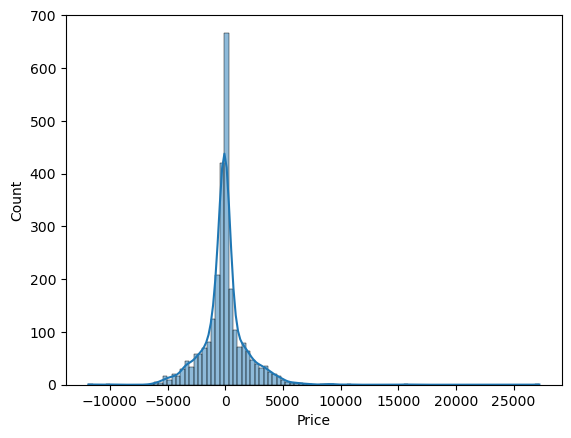

In [467]:
predict(RandomForestRegressor())

In [468]:
from sklearn.tree import DecisionTreeRegressor


This is the Trainig Score: 0.9678875584094965
Prediction are: [14158.5  3841.   4148.  ... 14151.  10844.   3841. ]


R2 Score: 0.6728705743532144
MAE: 1400.424630479103
MAPE: 0.15615504709407518


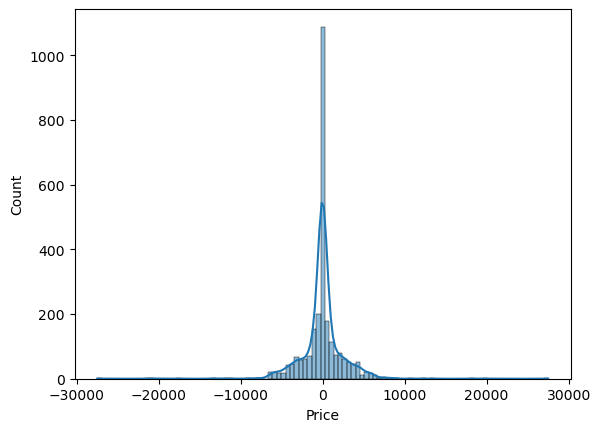

In [469]:
predict(DecisionTreeRegressor())

This is the Trainig Score: 0.7767422973365179
Prediction are: [14854.18295194  4085.2074517   4914.00993085 ... 12087.80725593
 12017.71881189  3743.16230533]


R2 Score: 0.7627048223693503
MAE: 1531.5452747135337
MAPE: 0.18503484411463514


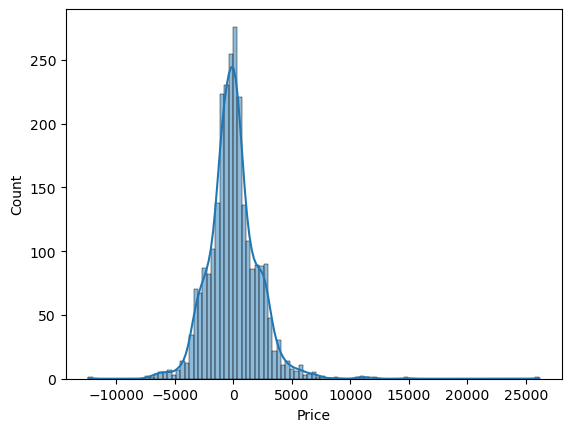

In [473]:
#boosting
from sklearn.ensemble import GradientBoostingRegressor
predict(GradientBoostingRegressor())

In [474]:
from sklearn.model_selection import RandomizedSearchCV

In [476]:
reg_rf=RandomForestRegressor()

In [477]:
np.linspace(start=100,stop=1200,num=6)

array([ 100.,  320.,  540.,  760.,  980., 1200.])

In [484]:
n_estimators=[int(x) for x in np.linspace(start=100,stop=1200,num=6)]
max_features=[None,"sqrt"]
max_depth=[int(x) for x in np.linspace(5,30,num=4)]
min_samples_split=[5,10,15,100]

In [485]:
random_grid={
    "n_estimators":n_estimators,
    "max_features":max_features,
    "max_depth":max_depth,
    "min_samples_split":min_samples_split
}

In [486]:
random_grid

{'n_estimators': [100, 320, 540, 760, 980, 1200],
 'max_features': [None, 'sqrt'],
 'max_depth': [5, 13, 21, 30],
 'min_samples_split': [5, 10, 15, 100]}

In [487]:
rf_random=RandomizedSearchCV(estimator=reg_rf,param_distributions=random_grid,n_iter=10,cv=3,verbose=2,random_state=42,n_jobs=-1)

In [488]:
rf_random.fit(train_X,train_y)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_split=100, n_estimators=760; total time=   1.8s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=100, n_estimators=760; total time=   1.7s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=100, n_estimators=760; total time=   1.7s
[CV] END max_depth=21, max_features=sqrt, min_samples_split=15, n_estimators=980; total time=   3.9s
[CV] END max_depth=21, max_features=sqrt, min_samples_split=15, n_estimators=980; total time=   4.1s
[CV] END max_depth=21, max_features=sqrt, min_samples_split=15, n_estimators=980; total time=   4.0s
[CV] END max_depth=13, max_features=sqrt, min_samples_split=5, n_estimators=980; total time=   4.3s
[CV] END max_depth=13, max_features=sqrt, min_samples_split=5, n_estimators=980; total time=   4.3s
[CV] END max_depth=21, max_features=sqrt, min_samples_split=100, n_estimators=1200; total time=   3.3s
[CV] END max_depth=21, max_fea

,estimator,RandomForestRegressor()
,param_distributions,"{'max_depth': [5, 13, ...], 'max_features': [None, 'sqrt'], 'min_samples_split': [5, 10, ...], 'n_estimators': [100, 320, ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [490]:
rf_random.best_params_

{'n_estimators': 1200,
 'min_samples_split': 15,
 'max_features': None,
 'max_depth': 21}

In [491]:
RandomForestRegressor(n_estimators=1200,
 min_samples_split=15,
 max_features=None,
 max_depth=21)

,n_estimators,1200
,criterion,'squared_error'
,max_depth,21
,min_samples_split,15
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [492]:
rf_random.best_score_

np.float64(0.8159471793564764)